# Analyse of the expenses

In [1]:
year = 'mid 2024 mid 2025'
csv_file = 'Depenses_Analyse_16062024_15062025.csv'

In [2]:
import pandas as pd
import matplotlib as mpl
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import ConnectionPatch
from termcolor import colored
from ipywidgets import *

# Function to apply the logic
def combine_df(df1, df2):
    df3 = pd.DataFrame(dtype='int')
    for row in range(0, len(df1)):
        for column in df1.columns:
            try:
                df3.at[row, column] = df1.at[row, column] + df2.at[row, column] / 2
            except:
                if df1.at[row, column] != "0" and df2.at[row, column] != "0":
                    df3.at[row, column] = f"{df1.at[row, column]}_{df2.at[row, column]}"
                elif df1.at[row, column] != "":
                    df3.at[row, column] = df1.at[row, column]
                elif df2.at[row, column] != "":
                    df3.at[row, column] = 0
                else:
                    df3.at[row, column] = ""
    
    for column in df3.columns:
        try:
            df3[column] = df3[column]
        except:
            df3[column] = df3[column]
    return df3


list_months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
list_colors = ['peru', 'gold', 'lightseagreen', 'plum', 'indianred', 'cornflowerblue', 'darkgrey', 'mediumpurple', 'steelblue', 'rosybrown', 'moccasin', 'skyblue', 'olive', 'peru', 'gold', 'lightseagreen', 'plum', 'indianred', 'cornflowerblue', 'darkgrey', 'mediumpurple', 'steelblue', 'rosybrown', 'moccasin', 'skyblue', 'olive', 'peru', 'gold', 'lightseagreen', 'plum', 'indianred', 'cornflowerblue', 'darkgrey', 'mediumpurple', 'steelblue', 'rosybrown', 'moccasin', 'skyblue', 'olive', 'peru', 'gold', 'lightseagreen', 'plum', 'indianred', 'cornflowerblue', 'darkgrey', 'mediumpurple', 'steelblue', 'rosybrown', 'moccasin', 'skyblue', 'olive']

df = pd.read_csv(csv_file, encoding='unicode_escape', header=[0, 1])

df_reduced_ju = df[df[('qui', 'qui')]=='ju'].drop('id_jour', axis=1, level=0)
df_reduced_su = df[df[('qui', 'qui')]=='su'].drop('id_jour', axis=1, level=0)
df_commun= df[df[('qui', 'qui')]=='co'].drop('id_jour', axis=1, level=0)

df_reduced_ju.reset_index(drop=True, inplace=True)
df_reduced_su.reset_index(drop=True, inplace=True)
df_commun.reset_index(drop=True, inplace=True)

nb_jour = len(df_reduced_ju)

print('The year studied is :')
print(colored(f'   {year}','cyan'))
print(colored(f'There is {str(nb_jour)} studied days.'))

#########################
df_every_day_life_ju = combine_df(df_reduced_ju['vie_quot'], df_commun['vie_quot'])
df_entertainment_ju = combine_df(df_reduced_ju['loisirs'], df_commun['loisirs'])
df_enfant_ju = combine_df(df_reduced_ju['enfant'], df_commun['enfant'])
df_admin_ju = combine_df(df_reduced_ju['admin'], df_commun['admin'])
df_fixed_costs_ju = combine_df(df_reduced_ju['fixes'], df_commun['fixes'])
df_all_ju = pd.concat([df_every_day_life_ju, df_entertainment_ju, df_enfant_ju, df_admin_ju, df_fixed_costs_ju], axis=1)
#########################
df_every_day_life_su = combine_df(df_reduced_su['vie_quot'], df_commun['vie_quot'])
df_entertainment_su = combine_df(df_reduced_su['loisirs'], df_commun['loisirs'])
df_enfant_su = combine_df(df_reduced_su['enfant'], df_commun['enfant'])
df_admin_su = combine_df(df_reduced_su['admin'], df_commun['admin'])
df_fixed_costs_su = combine_df(df_reduced_su['fixes'], df_commun['fixes'])
df_all_su = pd.concat([df_every_day_life_su, df_entertainment_su, df_enfant_su, df_admin_su, df_fixed_costs_su], axis=1)
#########################
list_df_every_day_life=[df_every_day_life_ju, df_every_day_life_su]
list_df_entertainment=[df_entertainment_ju, df_entertainment_su]
list_df_enfant=[df_enfant_ju, df_enfant_su]
list_df_admin=[df_admin_ju, df_admin_su]
list_df_fixed_costs=[df_fixed_costs_ju, df_fixed_costs_su]
list_df_all=[df_all_ju, df_all_su]
#########################
list_col_df_every_day_life = df_every_day_life_ju.columns.tolist()
list_col_df_every_day_life.remove('autre_info')
list_col_df_entertainment = df_entertainment_ju.columns.tolist()
list_col_df_entertainment.remove('autre_info')
list_col_df_enfant = df_enfant_ju.columns.tolist()
list_col_df_enfant.remove('autre_info')
list_col_df_admin = df_admin_ju.columns.tolist()
list_col_df_admin.remove('autre_info')
list_col_df_fixed_costs = df_fixed_costs_ju.columns.tolist()
list_col_df_fixed_costs.remove('autre_info')
list_col_df_all = list_col_df_every_day_life + list_col_df_entertainment + list_col_df_enfant + list_col_df_admin + list_col_df_fixed_costs
#########################
list_categories = ['Every Day Life', 'Entertainment', 'Child', 'Admin', 'Fixed Costs', 'All']
list_columns = [list_col_df_every_day_life, list_col_df_entertainment, list_col_df_enfant, list_col_df_admin, list_col_df_fixed_costs, list_col_df_all]
list_dfs = [list_df_every_day_life, list_df_entertainment, list_df_enfant, list_df_admin, list_df_fixed_costs, list_df_all]

ModuleNotFoundError: No module named 'pandas'

In [ ]:
#########################
def Convert_date(date): 
    date_split = date.split('_')
    appendix = 'th'
    if int(date_split[2][-1:]) == 1 and not int(date_split[2]) == 11: appendix = 'st'
    elif int(date_split[2][-1:]) == 2 and not int(date_split[2]) == 12: appendix = 'nd'
    elif int(date_split[2][-1:]) == 3 and not int(date_split[2]) == 13: appendix = 'rd'
        
    return str(date_split[2]) + appendix + ' of ' + list_months[int(date_split[1])-1] + ' ' + str(date_split[3])

#########################
def Extract_Max_Date_etc(df, list_extract, nb_jour):
    list_extract_label = []  ;  list_extract_total = []  ;  list_extract_ratio = []
    list_extract_bandes = []  ;  list_extract_date_max = []  ;  list_extract_bandes_date_center = []  ;  list_extract_studied = []

    j = 0
    for extract in list_extract:
        extract = abs(extract)
        count_level_0 = sum(x == 0 for x in extract)
        list_extract_total.append(sum(extract))  ;  list_extract_label.append(extract.name)  ;  list_extract_ratio.append((nb_jour - count_level_0)/nb_jour)
        
        list_max0_max1_max2 = [0, 0, 0]  ;  list_date_max = [0, 0, 0]  ;  list_date_center = [0, 0, 0]
        
        for i in range (0,3):
            if i == 0:  extract_replaced = extract.replace(1,2).replace(0,1).replace(2,0)
            if i == 1:  extract_replaced = extract.replace(2,0)
            if i == 2:  extract_replaced = extract.replace(1,0).replace(2,1)

            count_serie_extract = extract_replaced * (extract_replaced.groupby((extract_replaced != extract_replaced.shift()).cumsum()).cumcount() + 1)

            list_max0_max1_max2[i] = max(count_serie_extract)
            list_date_max[i] = Convert_date(df.Info_Date[count_serie_extract.idxmax()])
            list_date_center[i] = round((count_serie_extract.idxmax() - (max(count_serie_extract) / 2)))

        list_extract_bandes.append(list_max0_max1_max2)  ;  list_extract_date_max.append(list_date_max)
        list_extract_bandes_date_center.append(list_date_center)  ;  list_extract_studied.append(j)
        j += 1

    return [    list_extract_label, list_extract_total, list_extract_ratio,
                list_extract_bandes, list_extract_date_max, list_extract_bandes_date_center, list_extract_studied    ]

#########################
def Plot_Series(list_analysis, title, xlabel, ylabel):
    fig = plt.figure(figsize=(10, (2/3)*len(list_analysis[6])))

    plt.grid()  ;  plt.title(title)  ;  plt.xlabel(xlabel)  ;  plt.ylabel(ylabel)

    list_date_0 = []  ;  list_bande_0 = []
    list_date_1 = []  ;  list_bande_1 = []
    list_date_2 = []  ;  list_bande_2 = []

    for j in range (0, len(list_analysis[6])):
        list_date_0.append(list_analysis[5][j][0] + 1)
        list_bande_0.append(round(list_analysis[3][j][0] / 2)+1)
        
        list_date_1.append(list_analysis[5][j][1] + 1)
        list_bande_1.append(round(list_analysis[3][j][1] / 2)+1)
        
        list_date_2.append(list_analysis[5][j][2] + 1)
        list_bande_2.append(round(list_analysis[3][j][2] / 2))

    plt.errorbar(list_date_0, list_analysis[6], xerr=list_bande_0, ecolor=list_colors[1], yerr=None, fmt=' ', linewidth=30, label="Max Block without")

    if sum(list_date_2) == len(list_analysis[6]) and sum(list_bande_2) == 0:
        plt.errorbar(list_date_1, list_analysis[6], xerr=list_bande_1, ecolor=list_colors[2], yerr=None, fmt=' ', linewidth=30, label="Max Block with")
    else:
        plt.errorbar(list_date_1, list_analysis[6], xerr=list_bande_1, ecolor=list_colors[2], yerr=None, fmt=' ', linewidth=30, label="Max Block with Level 1")
        plt.errorbar(list_date_2, list_analysis[6], xerr=list_bande_2, ecolor=list_colors[3], yerr=None, fmt=' ', linewidth=30, label="Max Block with Level 2")

    plt.xticks(np.arange(0, nb_jour, 30.5), list_months)
    plt.yticks(np.arange(0, len(list_analysis[6]), 1), list_analysis[0])

    plt.figlegend(loc='upper center', bbox_to_anchor=(1.03, 0.6), labelspacing=3, borderpad=1.5)
    plt.show()

#########################
def Plot_Pie_Depenses(df, list_analysis, title):
    plt.figure(figsize=[8, 8])
    list_sum = [int(df[item].sum())/12 for item in list_analysis]
    colors = [list_colors[i] for i in range(0, len(list_analysis))]
    plt.pie(list_sum, labels=list_analysis, autopct=lambda pct: f"{int(round(pct/100.*sum(list_sum)))} €", startangle=140, colors=colors) #autopct='%1.1f%%', 
    plt.title(title)

    plt.show()

#########################
def Plot_Bars_Depenses(df, list_analysis, title):
    fig = plt.figure(figsize=[len(list_analysis), 5])
    list_sum = [int(df[item].sum()) for item in list_analysis]
    colors = [list_colors[i] for i in range(0, len(list_analysis))]
    bc = plt.bar(list_analysis, list_sum, width=1, color=colors)
    plt.ylim=(0, max(list_sum))
    plt.xticks(rotation=30, ha='right', rotation_mode='anchor')
    plt.yticks(np.arange(0, 1.1*max(list_sum), max(list_sum)), ['0', str(max(list_sum)) + ' euros'])

    plt.bar_label(bc, labels=list_sum, label_type='center')
    plt.title(title)

    plt.show()



Below is plotted the repartition of expenses in category Every Day Life during the year mid 2024 mid 2025.


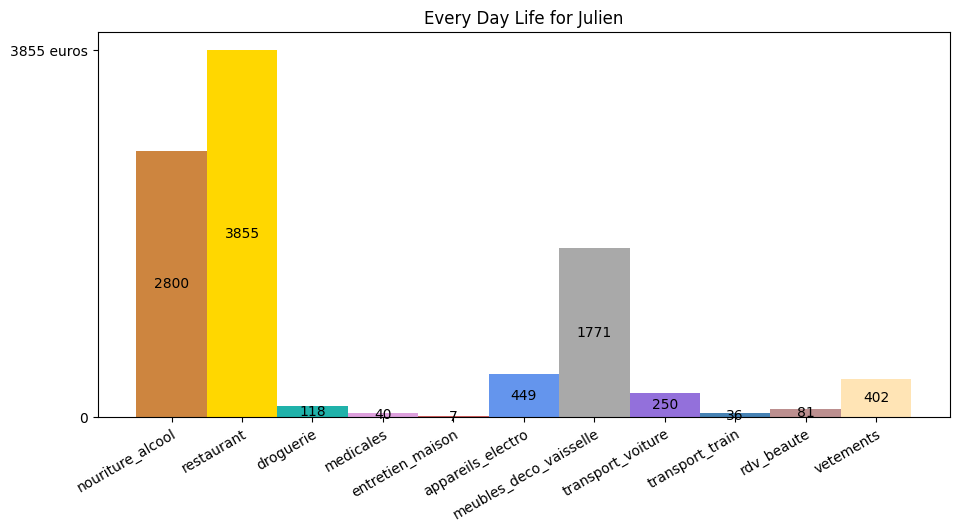

Julien spent 9812€ in the category Every Day Life


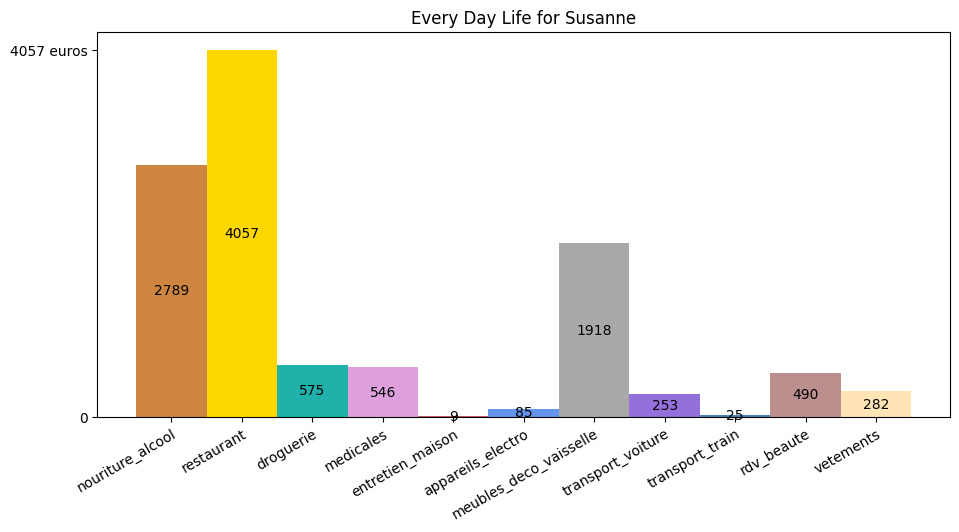

Susanne spent 11032€ in the category Every Day Life

Below is plotted the repartition of expenses in category Entertainment during the year mid 2024 mid 2025.


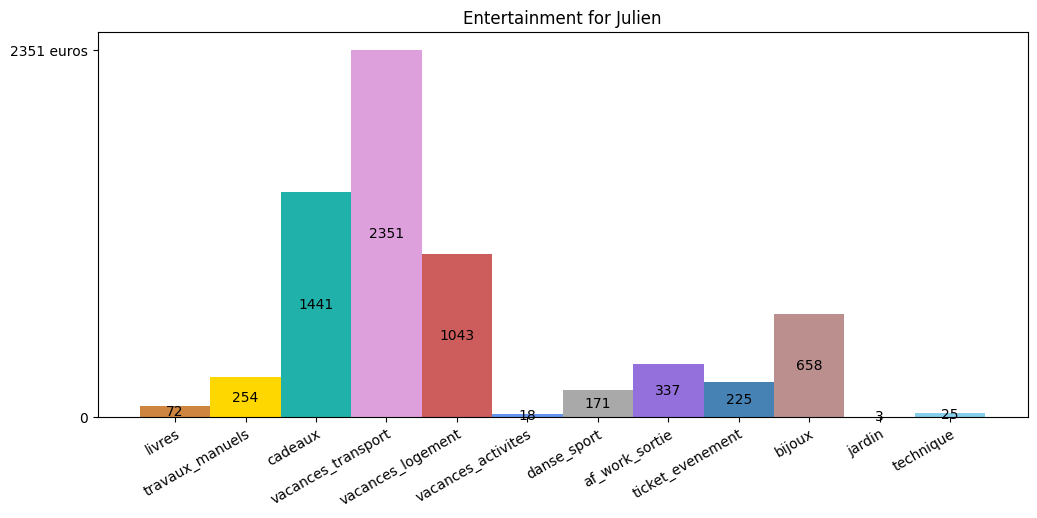

Julien spent 6600€ in the category Entertainment


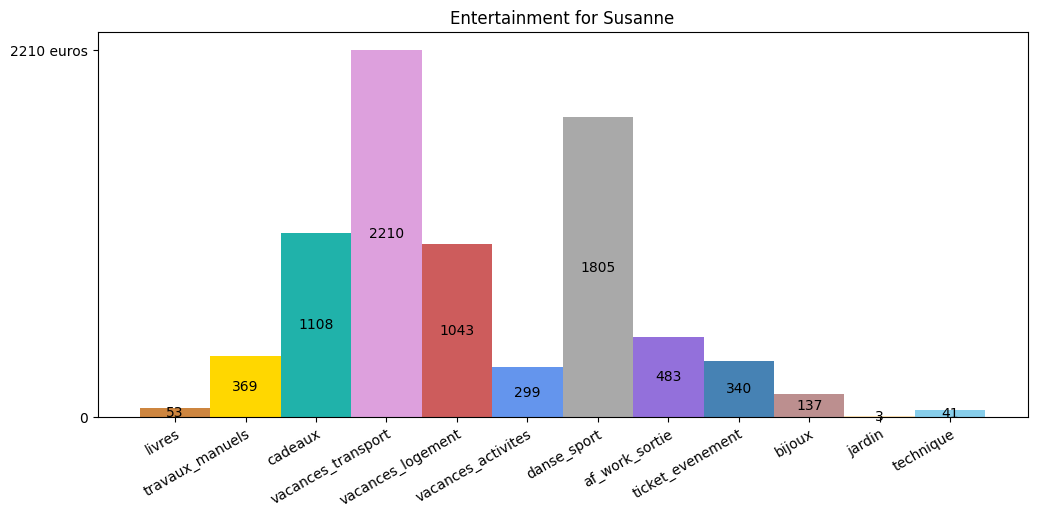

Susanne spent 7893€ in the category Entertainment

Below is plotted the repartition of expenses in category Child during the year mid 2024 mid 2025.


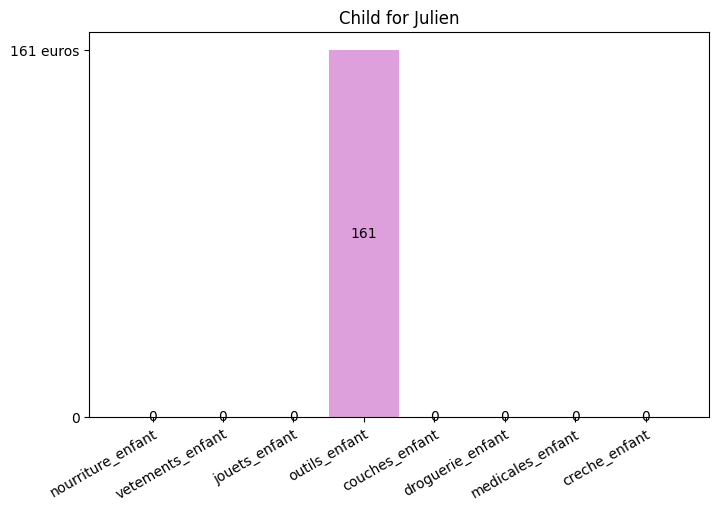

Julien spent 161€ in the category Child


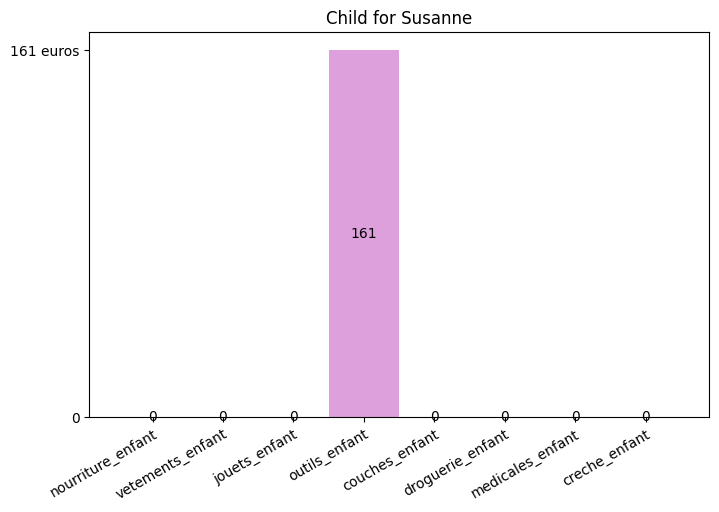

Susanne spent 161€ in the category Child

Below is plotted the repartition of expenses in category Admin during the year mid 2024 mid 2025.


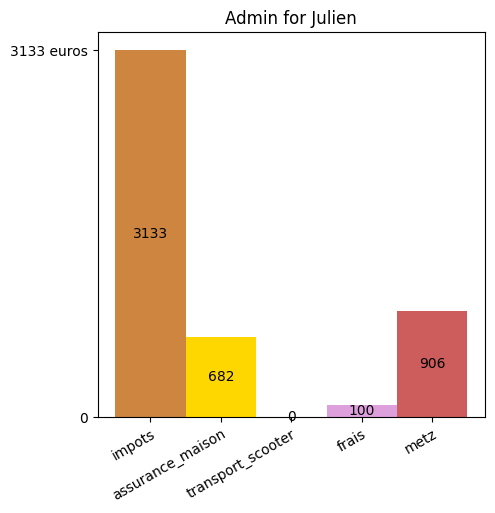

Julien spent 4822€ in the category Admin


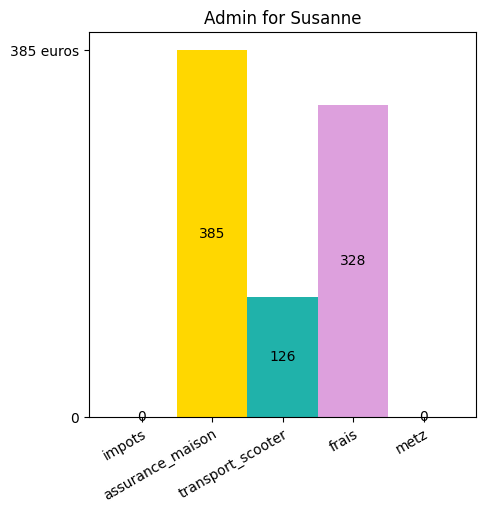

Susanne spent 840€ in the category Admin

Below is plotted the repartition of expenses in category Fixed Costs during the year mid 2024 mid 2025.


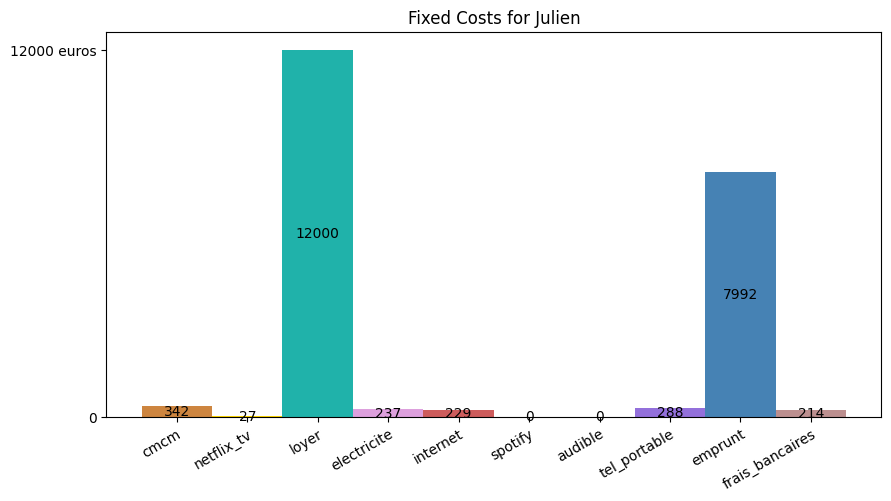

Julien spent 21330€ in the category Fixed Costs


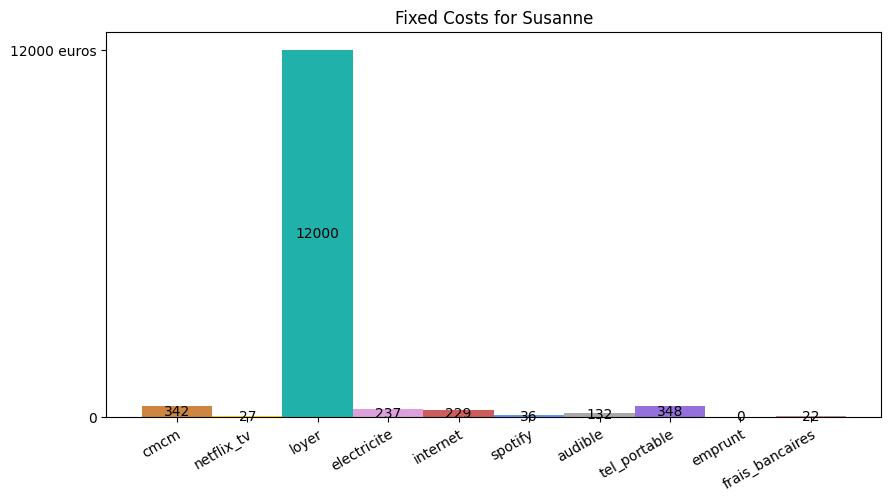

Susanne spent 13374€ in the category Fixed Costs

Below is plotted the repartition of expenses in category All during the year mid 2024 mid 2025.
Value divided by 12 to have a monthly average.


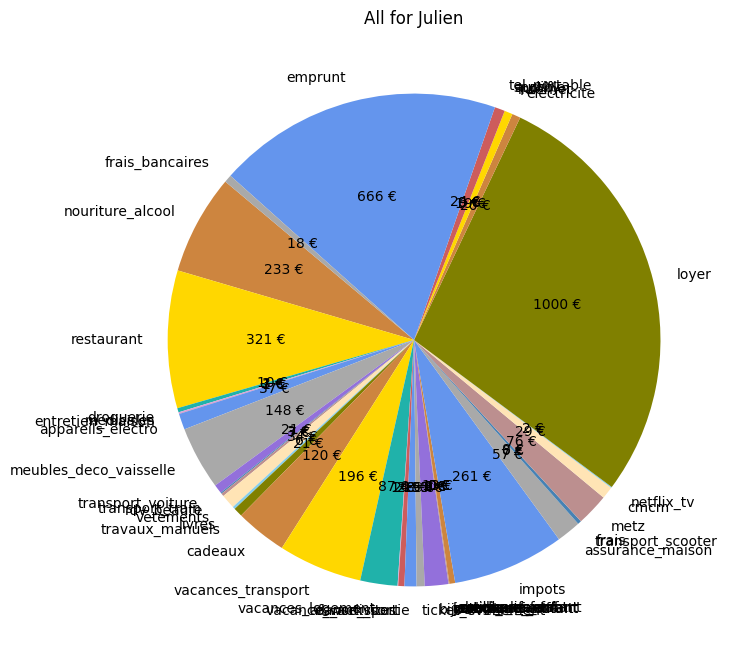

Julien spent 3560€ in the category All / month
                  Category    Value
38                   loyer  24000.0
44                 emprunt   7992.0
1               restaurant   7913.0
0         nouriture_alcool   5590.0
14      vacances_transport   4562.0
6   meubles_deco_vaisselle   3690.0
31                  impots   3133.0
13                 cadeaux   2549.0
15       vacances_logement   2087.0
17             danse_sport   1976.0
32        assurance_maison   1068.0
35                    metz    906.0
18          af_work_sortie    821.0
20                  bijoux    795.0
2                droguerie    694.0
10               vetements    684.0
36                    cmcm    684.0
43            tel_portable    636.0
12         travaux_manuels    624.0
3                medicales    587.0
9               rdv_beaute    571.0
19        ticket_evenement    565.0
5        appareils_electro    534.0
7        transport_voiture    504.0
39             electricite    475.0
40               

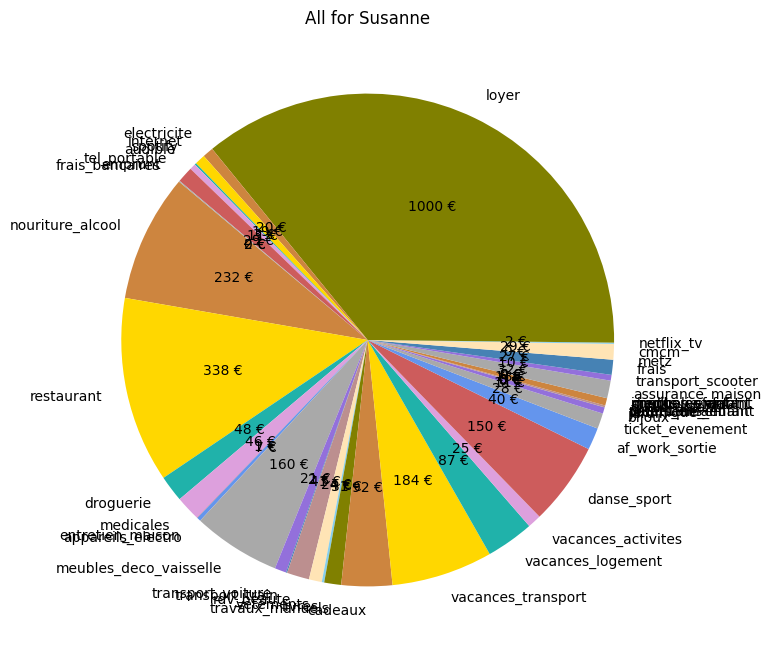

Susanne spent 2775€ in the category All / month

Below is presented the total spent by category in the house
         Category        Value
5             All  6335.666667
4     Fixed Costs  2892.083333
0  Every Day Life  1737.083333
1   Entertainment  1207.750000
3           Admin   471.833333
2           Child    26.916667


In [ ]:
dict_summary = {}

for i in range(len(list_categories)):
    category = list_categories[i]
    print(f'\nBelow is plotted the repartition of expenses in category {category} during the year {year}.')
    whoami = 'Julien'
    
    value_i = 0
    for df in list_dfs[i]:
        total_expenses = 0
        for column in df.columns:
            if column != 'autre_info':
                total_expenses = total_expenses + df[column].sum()

        value_i = value_i + total_expenses / 12

        if i == 5:
            if whoami == 'Julien':
                df_sum = df
            else:
                df_sum = df_sum + df
                column_sums = df_sum.drop(columns=["autre_info"]).sum().to_dict()
                df_sum = pd.DataFrame(list(column_sums.items()), columns=["Category", "Value"])
                df_sum_sorted = df_sum.sort_values(by="Value", ascending=False)
                print(df_sum_sorted)

            print(f'Value divided by 12 to have a monthly average.')
            Plot_Pie_Depenses(df, list_columns[i], f'{category} for {whoami}')
            print(f'{whoami} spent {int(total_expenses/12)}€ in the category {category} / month')
        else:
            Plot_Bars_Depenses(df, list_columns[i], f'{category} for {whoami}')
            print(f'{whoami} spent {int(total_expenses)}€ in the category {category}')
        whoami = 'Susanne'
    
    dict_summary[category] = value_i

df_summary = pd.DataFrame(list(dict_summary.items()), columns=["Category", "Value"])
df_summary_sorted = df_summary.sort_values(by="Value", ascending=False)

print("\nBelow is presented the total spent by category in the house")
print(df_summary_sorted)
